# M/M/C system simulation

## libraries

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

In [2]:
class mmc_sim:

    def __init__(self, entities, replications, tba_fn, arrival_rate, service_t_fn, service_rate):
        '''
        intializing state variables
        '''
        # cofig variables
        self.entities = entities
        self.rep = replications 

        # arrival variables
        self.arrival = 0
        self.tba = tba_fn
        self.arrival_rate = arrival_rate
        self.next_arrival = self.arrival + self.tba(self.arrival_rate)


        # service variables
        self.serive_start = 0
        self.service_time = service_t_fn
        self.service_rate = service_rate
        self.service_finish = self.serive_start + self.service_time(self.service_rate)

        # event table
        self.df_cols = ['Replication', 'Entity', 'Arrival_Time', 'Next_Arrival',
                         'Service_start', 'Service_finish']
        self.event_table = pd.DataFrame(columns=self.df_cols)

    def update_state(self):
        # arrival variables
        self.arrival = self.next_arrival
        self.next_arrival = self.arrival + self.tba(self.arrival_rate)

        # service variables
        self.serive_start = max(self.service_finish, self.arrival)
        self.service_finish = self.serive_start + self.service_time(self.service_rate)

    def reset(self):
        '''
        reset variables for rep
        '''
        # arrival variables
        self.arrival = 0
        self.next_arrival = self.arrival + self.tba(self.arrival_rate)


        # service variables
        self.serive_start = 0
        self.service_finish = self.serive_start + self.service_time(self.service_rate)



    def run_sim(self):
        '''
        function to process simulations
        '''

        for itr in range(1, self.rep+1):
            self.reset()
            for entity in range(1, self.entities + 1):
                # enter value into data frame
                row = pd.Series([itr, entity, 
                                 self.arrival, self.next_arrival,
                                 self.serive_start, self.service_finish],
                                 index=self.df_cols).to_frame().T
                
                # append to df
                self.event_table = pd.concat([self.event_table, row], ignore_index=True)

                # update step
                self.update_state()
            




## exponential sampling

In [3]:
# exponential time
def exp_time_diff(rate):
    return (-np.log(1-np.random.uniform())/rate).item()

## run simulation

In [4]:
entities = 10
replications = 100
tba_fn = exp_time_diff
arrival_rate = 1
service_t_fn = exp_time_diff
service_rate = 1.5

sim = mmc_sim(entities, replications, tba_fn, arrival_rate, service_t_fn, service_rate)
sim.run_sim()

C:\Users\prade\AppData\Local\Temp\ipykernel_18896\3505159143.py:68: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.event_table = pd.concat([self.event_table, row], ignore_index=True)


## get event table

In [5]:
df = sim.event_table.round(3)

## discrete statistics

https://www.youtube.com/watch?v=fRHkP5e-tMQ

get Wq and W

In [6]:
df['Wq'] = df.Service_start - df.Arrival_Time
df['W'] = df['Wq'] + 1/service_rate

df = df.round(3)


In [7]:
print(f'Wq: sample mean = {df.Wq.mean().round(3)}')
print(f'W: sample mean = {df.W.mean().round(3)}')

Wq: sample mean = 0.731
W: sample mean = 1.398


## get Continuous statistics
https://www.youtube.com/watch?v=LdrEYoiNfVQ

get L and Lq

In [8]:
# concatenating arrival, service and departure time in ascending order
arrival_df = df[['Replication', 'Entity', 'Arrival_Time']].rename(columns={'Arrival_Time': 'time'})
arrival_df['event_type'] = 'A'
in_service_df = df[['Replication', 'Entity', 'Service_start']].rename(columns={'Service_start': 'time'})
in_service_df['event_type'] = 'S'
depart_df = df[['Replication', 'Entity', 'Service_finish']].rename(columns={'Service_finish': 'time'})
depart_df['event_type'] = 'D'

df_l = pd.concat([arrival_df, in_service_df, depart_df])
df_l.sort_values(by=['Replication', 'time', 'Entity', 'event_type'], inplace=True)
df_l.reset_index(inplace=True, drop=True)

In [9]:
# finding dt
df_l['dt'] = df_l.time.diff()
df_l['dt'].loc[df_l['dt']<0] = 0


C:\Users\prade\AppData\Local\Temp\ipykernel_18896\2096209805.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_l['dt'].loc[df_l['dt']<0] = 0
C:\Users\prade\AppData\Local\Temp\ipykernel_18896\2096209805.py:3: SettingWithCopyWarning: 
A v

In [10]:
# using dummy variables for event type 
df_l = pd.concat([df_l,
                  pd.get_dummies(df_l['event_type'], dtype=int)],
                  axis=1)



In [11]:
# get number of entities in system
df_l['L'] = df_l['A'] - df_l['D']
df_l['L'] = df_l['L'].cumsum()

# get number of entities in queue
df_l['Lq'] = df_l['A'] - df_l['S']
df_l['Lq'] = df_l['Lq'].cumsum()


In [12]:
# weighted mean Lq and L

df_l['dt*lq'] = df_l['dt']*df_l['Lq']
df_l['dt*l'] = df_l['dt']*df_l['L']

df_w_l = df_l.groupby(['Replication']).agg({'dt*lq': 'sum', 'dt*l': 'sum', 'time': 'max'})

print(f'Lq: sample mean = {df_w_l.apply(lambda x: x['dt*lq']/ x['time'], axis=1).mean().round(3)}')
print(f'L: sample mean = {df_w_l.apply(lambda x: x['dt*l']/ x['time'], axis=1).mean().round(3)}')

Lq: sample mean = 1.345
L: sample mean = 1.582


In [13]:
x = [
    0,
0.204,
0.639,
1.879,
4.629,
5.149,
5.363,
5.636,
6.072,
6.208,
6.37,
6.757,
7.373,
7.968,
8.003,
9.675,
10.06,
10.5,
11.489,
11.886

]

In [14]:
y = [
    1,
0,
1,
0,
1,
2,
3,
2,
1,
2,
1,
2,
1,
0,
1,
0,
1,
0,
1,
0

]

Text(0.5, 1.0, 'Sample Path')

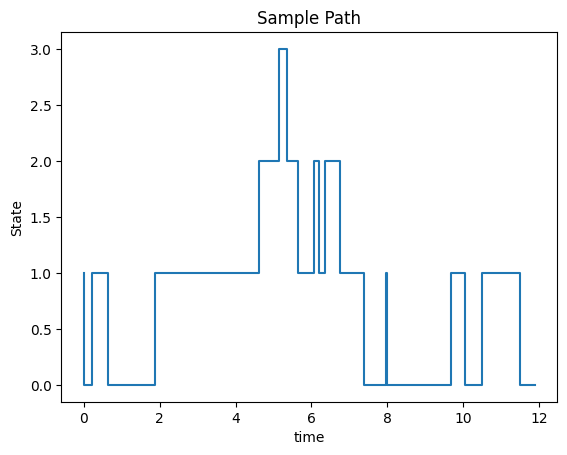

In [17]:
plt.step(x, y)
plt.xlabel('time')
plt.ylabel('State')
plt.title('Sample Path')